In [119]:
import numpy as np
from filterpy.kalman import ExtendedKalmanFilter
import joblib
from matplotlib import pyplot as plt
import pandas as pd
from scipy.signal import resample

**FIVE STARS**

In [120]:
# 0.9
# t_depth = 5
#transit depth
t_depth = 1.0
# t_depth = 0.5

#steepness of the curnce
sigma = .9

def h(theta):
    #the average flux (this should be zero bc I standardized the data)
    y0 = 0
    #transit depth

    thet = theta[0]
    result = y0 - t_depth*np.exp(-(1-np.cos(thet))/sigma)
    return np.array([float(result)])


def h_der(theta):
    thet = theta[0]
    result = (-t_depth*np.sin(thet)/sigma) * np.exp(-(1-np.cos(thet))/sigma)
    return np.array([[float(result), 0.0]])

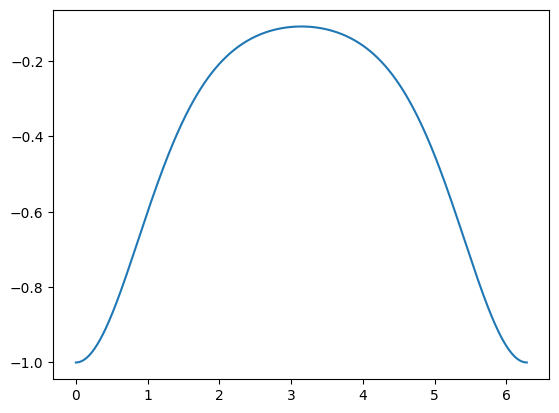

In [121]:
thetas_test = np.linspace(0, 2*np.pi, 500)
plt.plot(thetas_test, [h([th, 0])[0] for th in thetas_test])
plt.show()

In [122]:
#theta
G = 6.67e-11
dt = 0.01

dim_x = 2
dim_z = 1

# ekf = ExtendedKalmanFilter(dim_x, dim_z)

# #initial state, x = [theta, angular velocity]
# #I got my angular velocity from my first google search
# #2pi / period
# ekf.x = np.array([[np.pi], [7.26e-5]])
# ekf.P = np.eye(2)

# #Linear State
# ekf.F = np.array([[1.0, dt], [0.0, 1.0]])

# #Noise
# ekf.Q = np.eye(2)*1e-10
# # ekf.R = np.array([[20/10**6]])
# ekf.R = np.array([[1.0]])
# #ekf.R = np.array([[x*20/10**6]])

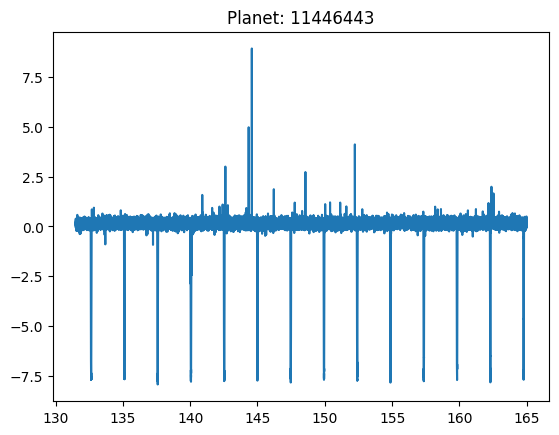

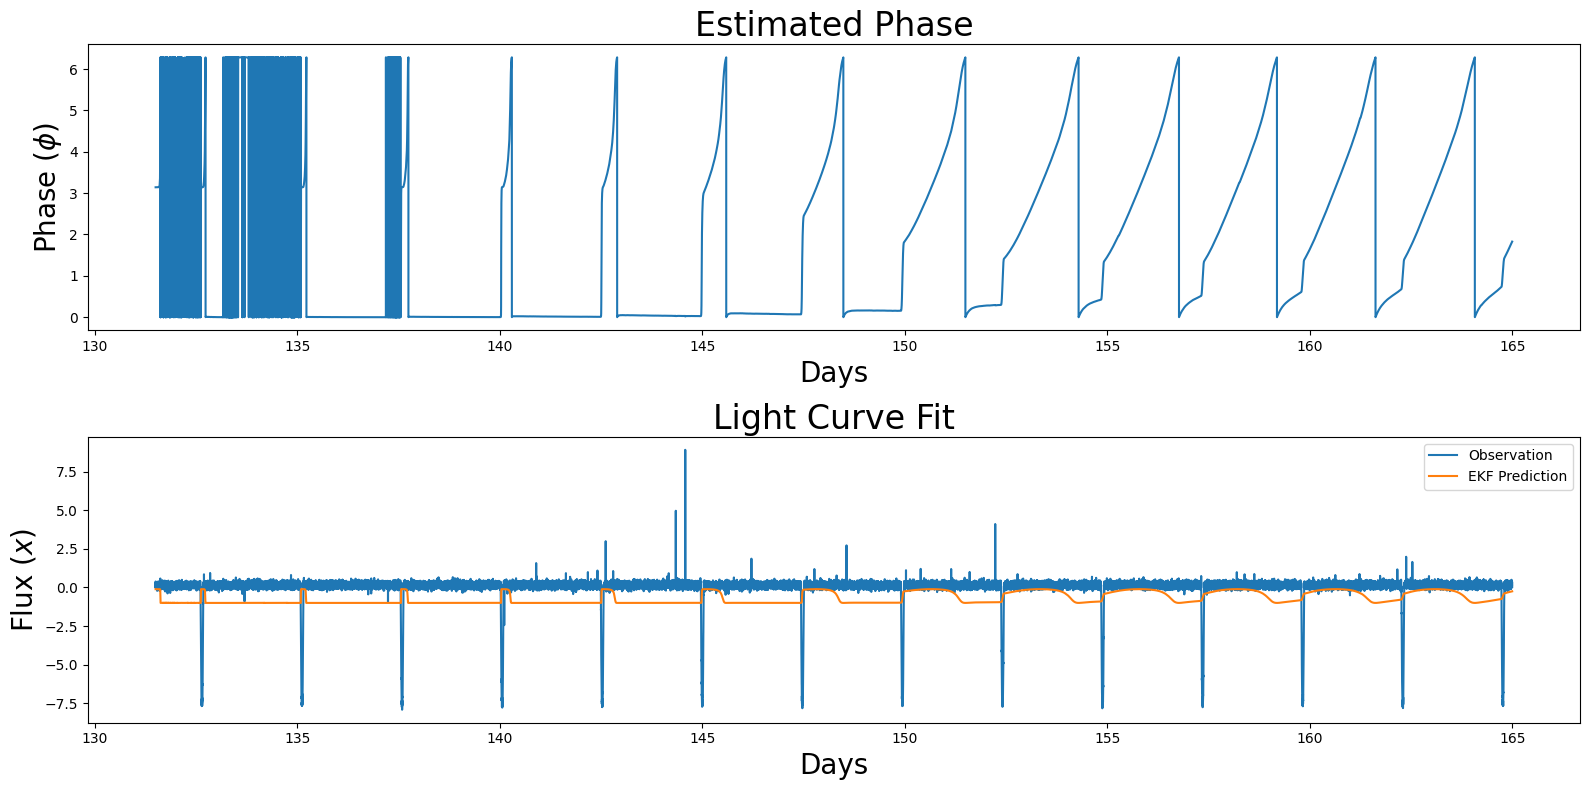

In [139]:
light_curve_dict = joblib.load("5_stars.joblib")
jobids = light_curve_dict.keys()
#vals is flux
for id in jobids:
    ekf = ExtendedKalmanFilter(dim_x, dim_z)
    ekf.x = np.array([[np.pi], [7.26e-5]])
    ekf.P = np.eye(2)
    ekf.F = np.array([[1.0, dt], [0.0, 1.0]])
    ekf.Q = np.eye(2)*1e-10
    ekf.R = np.array([[1.0]])

    vals = np.asarray(light_curve_dict[id]['flux'], dtype=float)
    t = np.asarray(light_curve_dict[id]['time'], dtype=float)

    #set nan_values to be the average of its neighbors
    nan_indices = np.argwhere(np.isnan(vals))
    for nan_index in nan_indices:
        vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

    valid_ind = np.where(np.isfinite(vals))[0]
    vals = vals[valid_ind]
    t = t[valid_ind]

    mean_v = np.mean(vals)
    std_v = np.std(vals)
    new_vals = (vals - mean_v) / std_v

    plt.plot(t, new_vals)
    plt.title(f'Planet: {id}')
    plt.show()

    thetas = []
    angular_vel = []
    for i, flux in enumerate(new_vals):
        ekf.predict()
        ekf.update(z=np.array([[flux]]), HJacobian=h_der, Hx=h)
        ekf.x[0][0] = ekf.x[0][0] % (2*np.pi)
        th, av = ekf.x.ravel()
        thetas.append(th)
        angular_vel.append(av)

    plt.figure(figsize=(16, 8))
    plt.subplot(211)
    #plot the observed measurements and then our thetas turned into brightness via H
    # plt.plot(t[::20], thetas[::20])
    plt.plot(t, thetas)
    plt.ticklabel_format(style='plain', axis='both', useOffset=False)
    plt.xlabel("Days", fontsize=20)
    plt.ylabel(r'Phase ($\phi$)', fontsize=20)
    plt.title(f"Estimated Phase", fontsize=24)
    # plt.savefig("EKFphase.png", dpi=300)
    # plt.show()


    plt.subplot(212)
    #plot the observed measurements and then our thetas turned into brightness via H
    # plt.figure(figsize=(16, 6))
    plt.plot(t, new_vals, label='Observation')
    plt.plot(t, [h([th, 0]) for th in thetas], label='EKF Prediction')

    plt.ticklabel_format(style='plain', axis='both', useOffset=False)
    plt.title(f"Light Curve Fit", fontsize=24)
    plt.xlabel("Days", fontsize=20)
    plt.ylabel(r"Flux ($x$)", fontsize=20)
    plt.legend()

    plt.tight_layout()
    plt.savefig("EKFflux.png", dpi=300)
    # plt.show()

    # plt.suptitle(f"Planet {id}")

    break

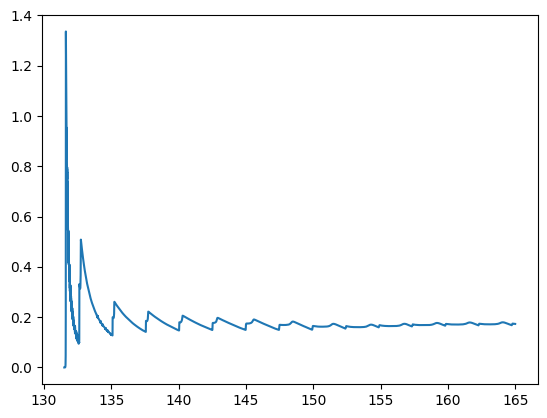

In [124]:
#plot the observed measurements and then our thetas turned into brightness via H
plt.plot(t, angular_vel)
plt.ticklabel_format(style='plain', axis='both', useOffset=False)

**DETRENDED**

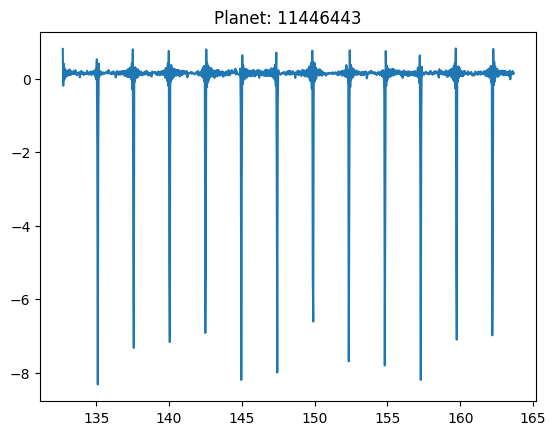

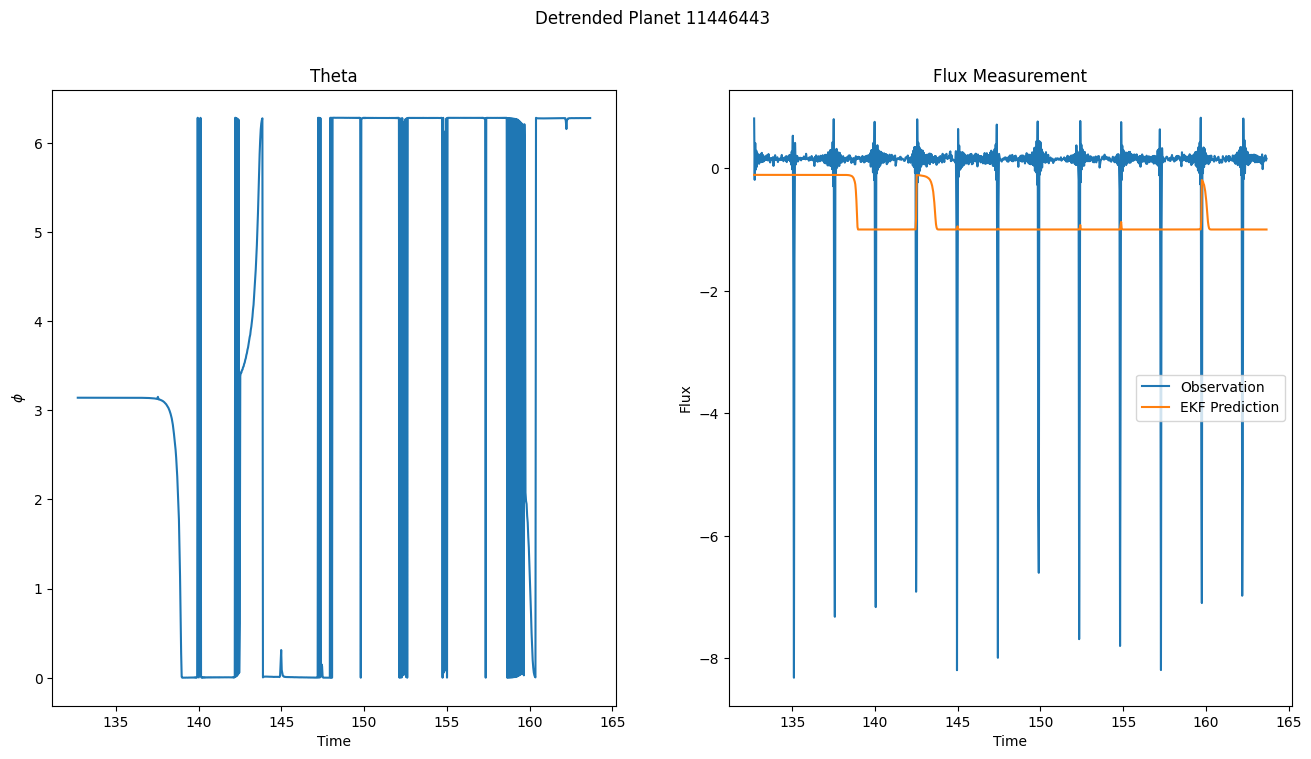

In [125]:
light_curve_dict = joblib.load("5_stars.joblib")
path ='GT/cumulative.csv'
period_df = pd.read_csv(path, usecols=['kepid', 'koi_period'])
jobids = list(light_curve_dict.keys())


jobids_set = set(jobids)
period_dict = {}

for chunk in pd.read_csv(path, usecols=['kepid', 'koi_period'], chunksize=1000):
    matches = chunk[chunk['kepid'].isin(jobids_set)]
    
    for _, row in matches.iterrows():
        period_dict[int(row['kepid'])] = row['koi_period']

    # Optional: stop early if we've found everything
    if len(period_dict) == len(jobids_set):
        break

def time_series_decomposition(df, estimated_period, id):
    # ==========================================
    # CLASSICAL DECOMPOSITION
    # ==========================================
    # Estimate Trend
    df = df.set_index('time')
    dt = np.mean(np.diff(df.index))
    window_size = int(estimated_period / dt)
    df['Trend_Estimate'] = df['Original'].rolling(window=window_size, center=True).mean()



    # Seasonality using phase
    df['phase'] = (df.index % estimated_period) / estimated_period

    # Estimate Seasonality (Average the detrended periods)
    df['Detrended'] = df['Original'] - df['Trend_Estimate']

    df_clean = df.dropna()

    return np.array(list(df_clean.index)), np.array(list(df_clean['Detrended']))
    
    # plt.plot(df.index, df['Detrended']) #, color='purple', marker='o', markersize=4)
    # plt.title(f'{id}')
    # plt.show()


for id in jobids:
    period = period_dict[id]

    vals = np.asarray(light_curve_dict[id]['flux'], dtype=float)
    t = np.asarray(light_curve_dict[id]['time'], dtype=float)

    valid_idx = np.where(np.isfinite(vals))[0]
    vals = vals[valid_idx]
    t = t[valid_idx]
    x_new, t_new = resample(vals, 1000, t=t)

    ts_df = pd.DataFrame({
    'time': t_new,
    'Original': x_new})

    #this is the detrended data
    t, vals = time_series_decomposition(ts_df, period, id)

    #   KALMAN FILTER HERE
    ekf = ExtendedKalmanFilter(dim_x, dim_z)
    ekf.x = np.array([[np.pi], [7.26e-5]])
    ekf.P = np.eye(2)
    ekf.F = np.array([[1.0, dt], [0.0, 1.0]])
    ekf.Q = np.eye(2)*1e-10
    ekf.R = np.array([[1.0]])
    #set nan_values to be the average of its neighbors
    nan_indices = np.argwhere(np.isnan(vals))
    for nan_index in nan_indices:
        vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

    valid_ind = np.where(np.isfinite(vals))[0]
    vals = vals[valid_ind]
    t = t[valid_ind]

    mean_v = np.mean(vals)
    std_v = np.std(vals)
    new_vals = (vals - mean_v) / std_v

    plt.plot(t, new_vals)
    plt.title(f'Planet: {id}')
    plt.show()

    thetas = []
    angular_vel = []
    for i, flux in enumerate(new_vals):
        ekf.predict()
        ekf.update(z=np.array([[flux]]), HJacobian=h_der, Hx=h)
        ekf.x[0][0] = ekf.x[0][0] % (2*np.pi)
        th, av = ekf.x.ravel()
        thetas.append(th)
        angular_vel.append(av)

    plt.figure(figsize=(16, 8))
    plt.subplot(121)
    #plot the observed measurements and then our thetas turned into brightness via H
    # plt.plot(t[::20], thetas[::20])
    plt.plot(t, thetas)
    plt.ticklabel_format(style='plain', axis='both', useOffset=False)
    plt.title(f"Theta")
    plt.xlabel("Time")
    plt.ylabel(rf"$\phi$")

    plt.subplot(122)
    #plot the observed measurements and then our thetas turned into brightness via H
    plt.plot(t, new_vals, label='Observation')

    plt.plot(t, [h([th, 0]) for th in thetas], label='EKF Prediction')
    plt.ticklabel_format(style='plain', axis='both', useOffset=False)
    plt.title(f"Flux Measurement")
    plt.xlabel("Time")
    plt.legend()
    plt.ylabel('Flux')

    plt.suptitle(f"Detrended Planet {id}")
    plt.savefig("EKFdetrend.png", dpi=300)

    break